While the underlying logic is the same, the framework implementation provides better Numerical Robustness and optimized Parameter Initialization , which leads to better convergence in practice.

In [ ]:
import torch
import random
import matplotlib.pyplot as plt


In [45]:
def synthetic_data(w, b, num_examples):
    #生成带噪声的线性回归数据集
    X = torch.normal(0, 1, (num_examples, len(w)))#正态分布,生成形状为(num_examples, len(w))的张量
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)#加入噪声
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

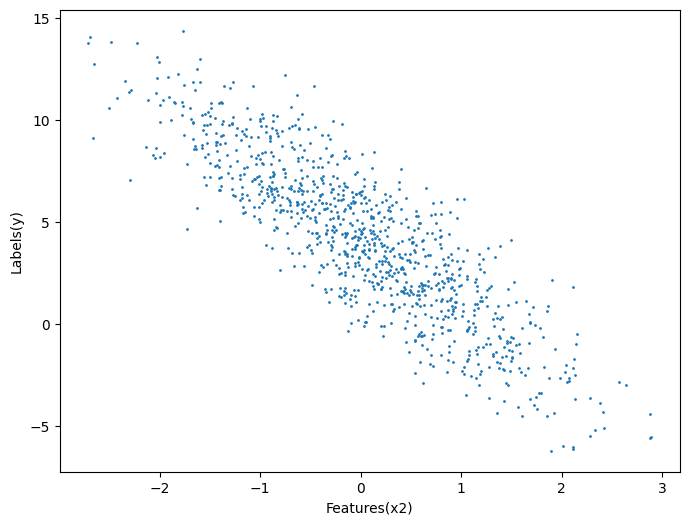

In [46]:
#画出散点图
def plot_scatter(features, labels):
    plt.figure(figsize=(8, 6))

    plt.scatter(features[:, 1].detach().numpy(), 
                labels.detach().numpy(), 
                s=1)
    plt.xlabel('Features(x2)')
    plt.ylabel('Labels(y)') 
    plt.show()

plot_scatter(features, labels)
    

In [47]:
#读取数据集
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices) #打乱顺序
    
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)]
        )
        yield features[batch_indices], labels[batch_indices]

batch_size = 10    

In [48]:
#从零开始实现
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)#初始化参数
b = torch.zeros(1, requires_grad=True)

In [49]:
def linreg(X, w, b):
    #线性回归模型
    return torch.matmul(X, w) + b

def squared_loss(y_hat, y):
    #均方损失
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

In [50]:
def sgd(params, lr, batch_size):
    #随机梯度下降
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

In [51]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)
        # l形状是(batch_size,1)，而不是一个标量。l中的所有元素被加到一起，
        l.sum().backward()
        sgd([w, b], lr, batch_size)  # 使用参数的梯度更新参数
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.044514
epoch 2, loss 0.000178
epoch 3, loss 0.000048


In [52]:
#简洁实现
from torch import nn
from torch.utils import data
net = nn.Sequential(nn.Linear(2, 1))

In [53]:
def load_array(data_arrays, batch_size, is_train=True):  
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset, batch_size, shuffle=is_train)

batch_size = 10
data_iter = load_array((features, labels), batch_size)

In [54]:
net[0].weight.data.normal_(0, 0.01)
net[0].bias.data.fill_(0)

tensor([0.])

In [55]:
loss = nn.MSELoss()
trainer = torch.optim.SGD(net.parameters(), lr=0.03)

In [56]:
num_epochs = 3
for epoch in range(num_epochs):
    for X, y in data_iter:
        l = loss(net(X) ,y)
        trainer.zero_grad()
        l.backward()
        trainer.step()
    l = loss(net(features), labels)
    print(f'epoch {epoch + 1}, loss {l:f}')

epoch 1, loss 0.000315
epoch 2, loss 0.000097
epoch 3, loss 0.000096
